# Test case A: 2D circle with arc remove

In [1]:
# setup imports
import matplotlib.pyplot as plt
import numpy as np
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from persim import bottleneck


/Users/steven/repos/weekend-tda/.venv/lib/python3.12/site-packages/persim/landscapes/visuals.py:310: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ls[:, 0], ls[:, 1], label=f"$\lambda_{{{depth}}}$", alpha=alpha)
/Users/steven/repos/weekend-tda/.venv/lib/python3.12/site-packages/persim/landscapes/visuals.py:469: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(domain, l, label=f"$\lambda_{{{depth}}}$", alpha=alpha)


In [2]:
# create the full circle:
n = 200
theta = np.linspace(0, 2 * np.pi, n, endpoint=False)
# (cos(θ), sin(θ)) for θ in [0, 2π/n, 4π/n, ..., 2π(n-1)/n]
full = np.stack([np.cos(theta), np.sin(theta)], axis=1)

# create a circle with a 60-degree arc removed:
mask = ~((theta > np.pi/2) & (theta < np.pi/2 + np.pi/3))
broken = full[mask]

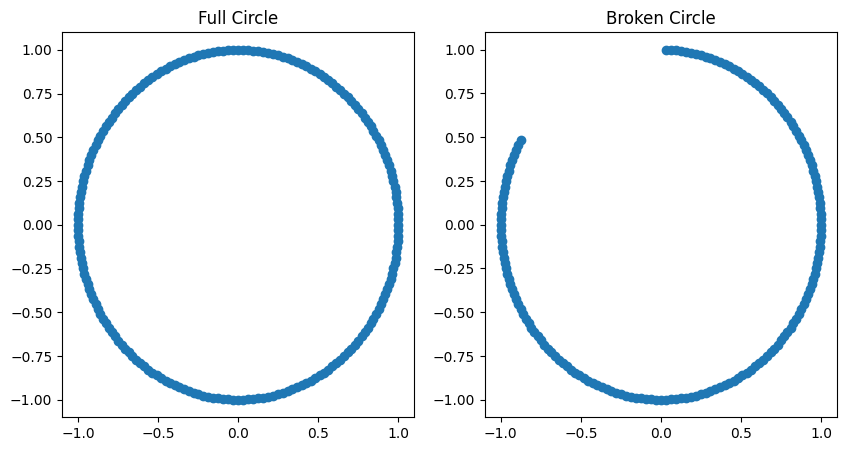

In [3]:
# plot the two circles:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(full[:, 0], full[:, 1])
axes[0].set_title("Full Circle")
axes[1].scatter(broken[:, 0], broken[:, 1])
axes[1].set_title("Broken Circle")
plt.show()

In [4]:
# calculate our persistence diagrams:
vr = VietorisRipsPersistence(homology_dimensions=[0, 1])
diag_full = vr.fit_transform(full[None, ...])
diag_broken = vr.fit_transform(broken[None, ...])

In [5]:
plot_diagram(diag_full[0]).show()

In [6]:
plot_diagram(diag_broken[0]).show()

## Test Case B: 2 clusters

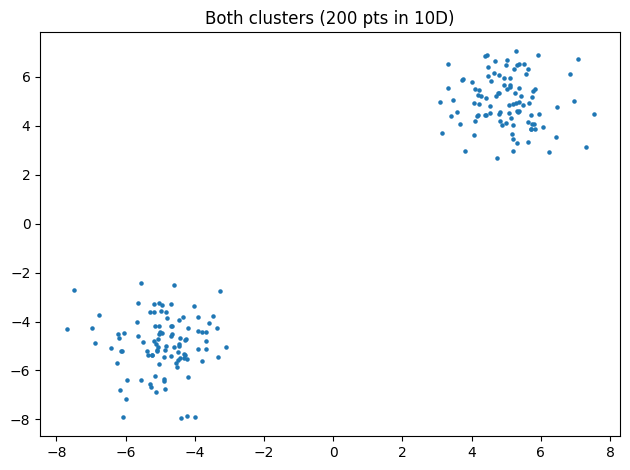

In [7]:
np.random.seed(42)
cluster_a = np.random.randn(100, 10) + np.array([5]*10)
cluster_b = np.random.randn(100, 10) - np.array([5]*10)
both = np.vstack([cluster_a, cluster_b])
only_a = cluster_a

diag_both = vr.fit_transform(both[None, ...])
diag_a = vr.fit_transform(only_a[None, ...])

plt.scatter(both[:, 0], both[:, 1], s=5)
plt.title("Both clusters (200 pts in 10D)")
plt.tight_layout()
plt.show()


We see a whole bunch of noise along the diagonal because the `H1` feature isn't actually persistent. And, as expected, at a large enough scale, the two clusters merge into one component. Hence the persistent `H0` feature. But more importantly: the gap between the top 2 `H0` features indicates a "real" separation.

In [8]:
plot_diagram(diag_both[0]).show()

Demonstrating this idea with 3 distinct clusters, shows 2 distinct `H0` features:

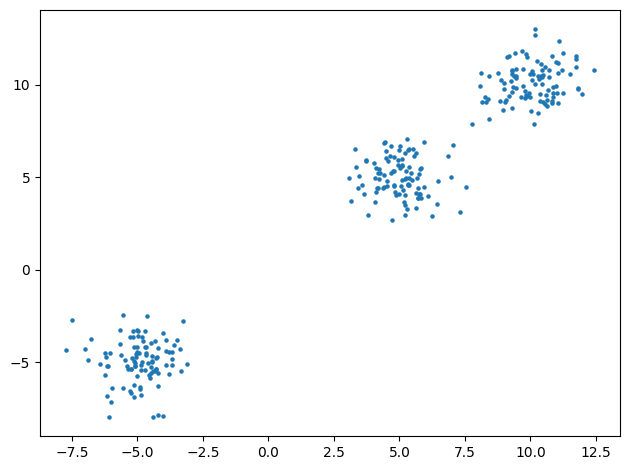

In [9]:
np.random.seed(42)
cluster_a = np.random.randn(100, 10) + np.array([5]*10)
cluster_b = np.random.randn(100, 10) - np.array([5]*10)
cluster_c = np.random.randn(100, 10) + np.array([10]*10)
both = np.vstack([cluster_a, cluster_b, cluster_c])

diag_both = vr.fit_transform(both[None, ...])

plt.scatter(both[:, 0], both[:, 1], s=5)
plt.tight_layout()
plt.show()

plot_diagram(diag_both[0]).show()

### Test case C: High-dim sphere with chunk removed

Note: H_1 of S^9 is trivial — the meaningful feature would be H_9, but computing high-dim homology is expensive. We're really testing whether *anything* changes detectably.

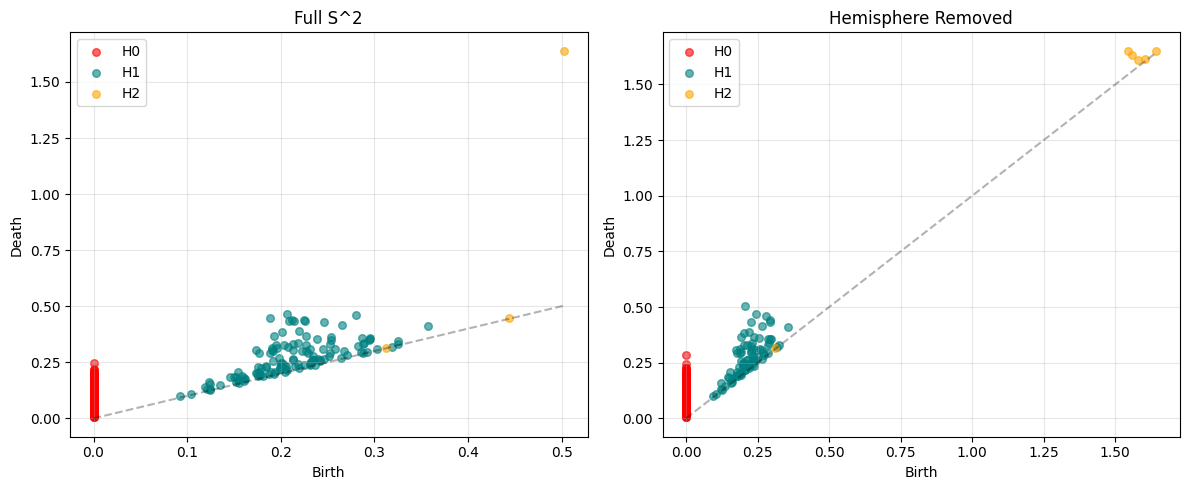

H2 bottleneck distance: 0.5684


In [3]:
# Sample uniformly on the 2-sphere in R^3
n = 500
pts = np.random.randn(n, 3)
pts = pts / np.linalg.norm(pts, axis=1, keepdims=True)

# Remove one "hemisphere" (e.g., points where first coordinate > 0.5)
mask = pts[:, 0] < 0.5
hemisphere_removed = pts[mask]


vr_hd = VietorisRipsPersistence(homology_dimensions=[0, 1, 2])
diag_full_s = vr_hd.fit_transform(pts[None, ...])
diag_cut_s = vr_hd.fit_transform(hemisphere_removed[None, ...])
plot_diagram(diag_cut_s[0]).show()
plot_diagram(diag_full_s[0]).show()

# Compare persistence diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {0: "red", 1: "teal", 2: "orange"}
labels = {0: "H0", 1: "H1", 2: "H2"}

for idx, (diag, title) in enumerate([(diag_full_s, 'Full S^2'), (diag_cut_s, 'Hemisphere Removed')]):
    ax = axes[idx]
    diag_flat = diag[0]
    for dim in [0, 1, 2]:
        d = diag_flat[diag_flat[:, 2] == dim]
        ax.scatter(d[:, 0], d[:, 1], c=colors[dim], s=30, alpha=0.6, label=labels[dim])
    ax.plot([0, diag_flat[:, 0].max()], [0, diag_flat[:, 0].max()], 'k--', alpha=0.3)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Extract just H2 features as (birth, death) pairs
h2_full = diag_full_s[0][diag_full_s[0][:, 2] == 2][:, :2]
h2_cut  = diag_cut_s[0][diag_cut_s[0][:, 2] == 2][:, :2]

d = bottleneck(h2_full, h2_cut)
print(f"H2 bottleneck distance: {d:.4f}")


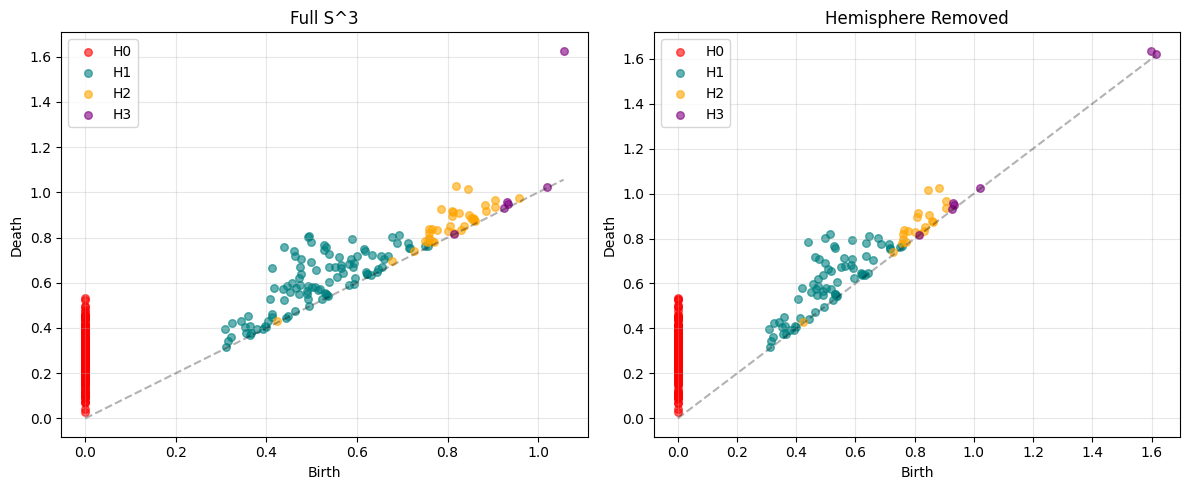

H2 bottleneck distance: 0.2853


In [ ]:
# Sample uniformly on the 3-sphere in R^4
n = 200
pts = np.random.randn(n, 4)
pts = pts / np.linalg.norm(pts, axis=1, keepdims=True)

# Remove one "hemisphere" (e.g., points where first coordinate > 0.5)
mask = pts[:, 0] < 0.5
hemisphere_removed = pts[mask]

dims = [0, 1, 2, 3]

vr_hd = VietorisRipsPersistence(homology_dimensions=dims)
diag_full_s = vr_hd.fit_transform(pts[None, ...])
diag_cut_s = vr_hd.fit_transform(hemisphere_removed[None, ...])
# plot_diagram(diag_cut_s[0]).show()
# plot_diagram(diag_full_s[0]).show()

# Compare persistence diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {0: "red", 1: "teal", 2: "orange", 3: "purple"}
labels = {0: "H0", 1: "H1", 2: "H2", 3: "H3"}

for idx, (diag, title) in enumerate([(diag_full_s, 'Full S^3'), (diag_cut_s, 'Hemisphere Removed')]):
    ax = axes[idx]
    diag_flat = diag[0]
    for dim in dims:
        d = diag_flat[diag_flat[:, 2] == dim]
        ax.scatter(d[:, 0], d[:, 1], c=colors[dim], s=30, alpha=0.6, label=labels[dim])
    ax.plot([0, diag_flat[:, 0].max()], [0, diag_flat[:, 0].max()], 'k--', alpha=0.3)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Extract just H2 features as (birth, death) pairs
h2_full = diag_full_s[0][diag_full_s[0][:, 2] == dims[-1]][:, :2]
h2_cut  = diag_cut_s[0][diag_cut_s[0][:, 2] == dims[-1]][:, :2]

d = bottleneck(h2_full, h2_cut)
print(f"H3 bottleneck distance: {d:.4f}")


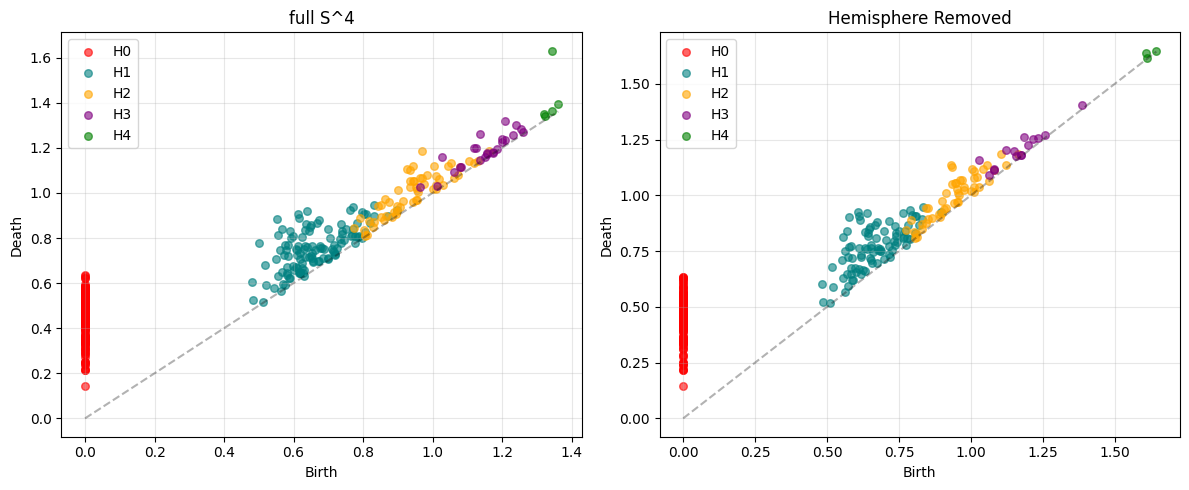

H4 bottleneck distance: 0.1434


In [19]:
# Sample uniformly on the 4-sphere in R^5
n = 150
dimension = 5
pts = np.random.randn(n, dimension)
pts = pts / np.linalg.norm(pts, axis=1, keepdims=True)

# Remove one "hemisphere" (e.g., points where first coordinate > 0.5)
mask = pts[:, 0] < 0.5
hemisphere_removed = pts[mask]

dims = [x for x in range(dimension)]  # [0, 1, 2, 3, 4]

vr_hd = VietorisRipsPersistence(homology_dimensions=dims)
diag_full_s = vr_hd.fit_transform(pts[None, ...])
diag_cut_s = vr_hd.fit_transform(hemisphere_removed[None, ...])
# plot_diagram(diag_cut_s[0]).show()
# plot_diagram(diag_full_s[0]).show()

# Compare persistence diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = {0: "red", 1: "teal", 2: "orange", 3: "purple", 4: "green"}
labels = {0: "H0", 1: "H1", 2: "H2", 3: "H3", 4: "H4"}

for idx, (diag, title) in enumerate([(diag_full_s, f"full S^{dims[-1]}"), (diag_cut_s, 'Hemisphere Removed')]):
    ax = axes[idx]
    diag_flat = diag[0]
    for dim in dims:
        d = diag_flat[diag_flat[:, 2] == dim]
        ax.scatter(d[:, 0], d[:, 1], c=colors[dim], s=30, alpha=0.6, label=labels[dim])
    ax.plot([0, diag_flat[:, 0].max()], [0, diag_flat[:, 0].max()], 'k--', alpha=0.3)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Extract just H2 features as (birth, death) pairs
h2_full = diag_full_s[0][diag_full_s[0][:, 2] == dims[-1]][:, :2]
h2_cut  = diag_cut_s[0][diag_cut_s[0][:, 2] == dims[-1]][:, :2]

d = bottleneck(h2_full, h2_cut)
print(f"H{dims[-1]} bottleneck distance: {d:.4f}")


H4 features in sample 0: 8


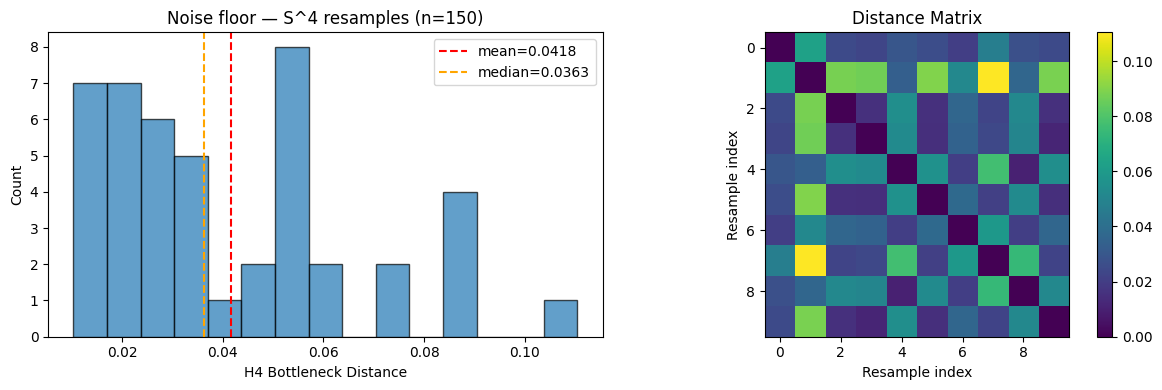

min=0.0103  max=0.1105  mean=0.0418  std=0.0247


In [24]:
def sample_sphere(n_pts, dim_ambient, seed):
    rng = np.random.default_rng(seed)
    pts = rng.standard_normal((n_pts, dim_ambient))
    return pts / np.linalg.norm(pts, axis=1, keepdims=True)

n_pts   = 150
d_amb   = 5          # S^2 in R^3
top_dim = d_amb - 1  # H2 is the meaningful class

vr = VietorisRipsPersistence(homology_dimensions=list(range(d_amb)))

# Batch all resamples — giotto-tda expects (n_samples, n_pts, n_dims)
samples       = np.stack([sample_sphere(n_pts, d_amb, s) for s in range(10)])  # (10, 300, 3)
diags_resample = vr.fit_transform(samples)  # (10, n_features, 3)

print(f"H{top_dim} features in sample 0: {(diags_resample[0][:, 2] == top_dim).sum()}")

from itertools import combinations

n_resamples = diags_resample.shape[0]
results = {}
for i, j in combinations(range(n_resamples), 2):
    di = diags_resample[i]
    dj = diags_resample[j]
    h_i = di[di[:, 2] == top_dim][:, :2]
    h_j = dj[dj[:, 2] == top_dim][:, :2]
    results[(i, j)] = bottleneck(h_i, h_j)

distances = np.array(list(results.values()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(distances, bins=15, edgecolor='black', alpha=0.7)
axes[0].axvline(distances.mean(), color='red',    linestyle='--', label=f'mean={distances.mean():.4f}')
axes[0].axvline(np.median(distances), color='orange', linestyle='--', label=f'median={np.median(distances):.4f}')
axes[0].set_xlabel(f'H{top_dim} Bottleneck Distance')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Noise floor — S^{top_dim} resamples (n={n_pts})')
axes[0].legend()

mat = np.zeros((n_resamples, n_resamples))
for (i, j), v in results.items():
    mat[i, j] = v
    mat[j, i] = v

im = axes[1].imshow(mat, cmap='viridis')
axes[1].set_title('Distance Matrix')
axes[1].set_xlabel('Resample index')
axes[1].set_ylabel('Resample index')
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"min={distances.min():.4f}  max={distances.max():.4f}  mean={distances.mean():.4f}  std={distances.std():.4f}")


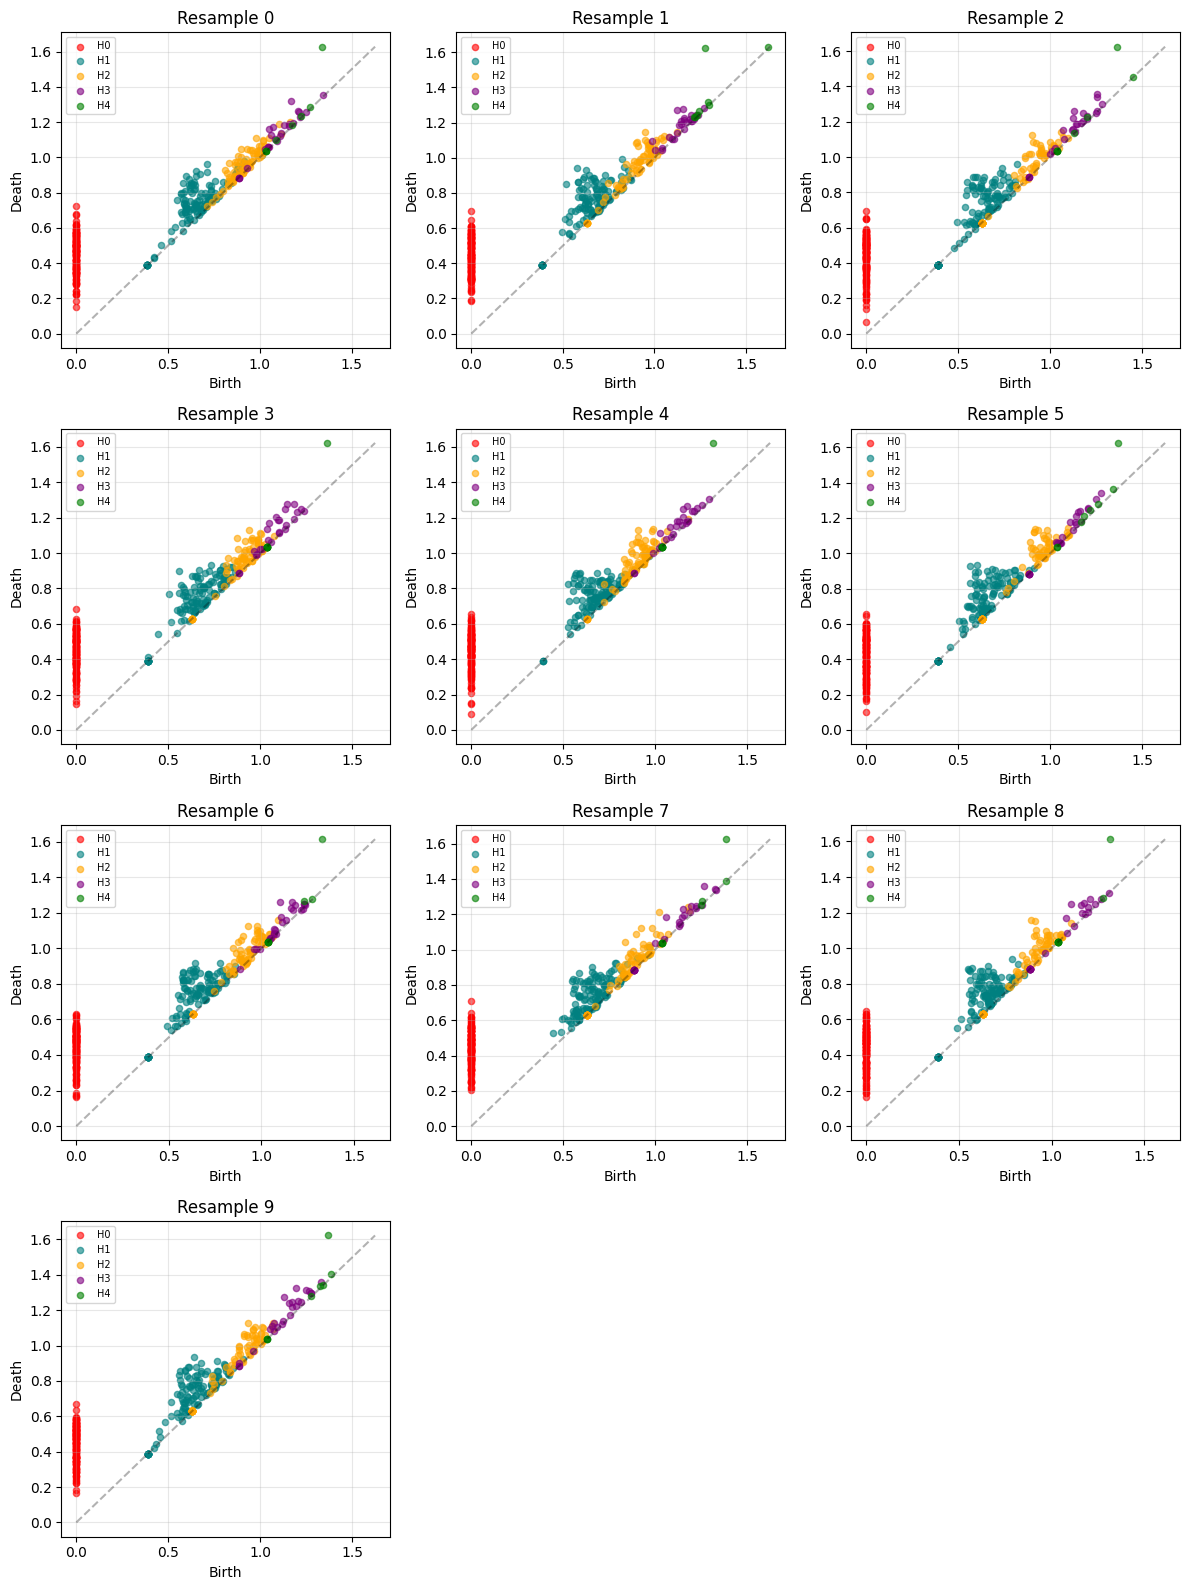

In [26]:
n_cols = 3
n_rows = (n_resamples + n_cols - 1) // n_cols
colors = {0: 'red', 1: 'teal', 2: 'orange', 3: 'purple', 4: 'green'}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = axes.flatten()

for idx in range(n_resamples):
    ax = axes[idx]
    diag = diags_resample[idx]
    finite = diag[diag[:, 1] < np.inf]
    max_val = finite[:, :2].max() if len(finite) > 0 else 1.0

    for dim in range(d_amb):
        d = diag[(diag[:, 2] == dim) & (diag[:, 1] < np.inf)]
        if len(d):
            ax.scatter(d[:, 0], d[:, 1], c=colors.get(dim, 'gray'),
                       s=20, alpha=0.6, label=f'H{dim}')

    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3)
    ax.set_title(f'Resample {idx}')
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for idx in range(n_resamples, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


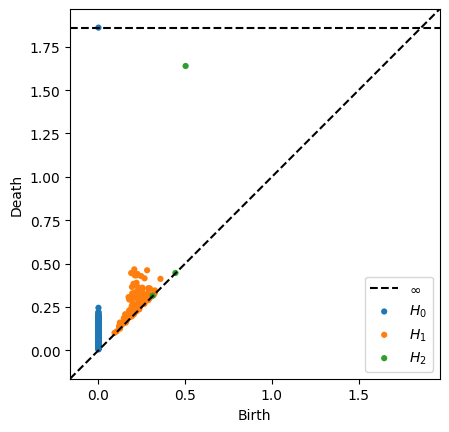

In [27]:
from ripser import ripser
from persim import bottleneck, plot_diagrams

dgms = ripser(pts, maxdim=2)['dgms']  # list of arrays per dim, no batch dim needed
plot_diagrams(dgms, show=True)


In [ ]:
# Sample uniformly on the 9-sphere in R^10
n = 500
pts = np.random.randn(n, 10)
pts = pts / np.linalg.norm(pts, axis=1, keepdims=True)

# Remove one "hemisphere" (e.g., points where first coordinate > 0.5)
mask = pts[:, 0] < 0.5
hemisphere_removed = pts[mask]

# Note: H_1 of S^9 is trivial — the meaningful feature would be H_9, but
# computing high-dim homology is expensive. We're really testing whether
# *anything* changes detectably.

vr_hd = VietorisRipsPersistence(homology_dimensions=[0, 1, 2])
diag_full_s = vr_hd.fit_transform(pts[None, ...])
diag_cut_s = vr_hd.fit_transform(hemisphere_removed[None, ...])
plot_diagram(diag_cut_s[0]).show()
plot_diagram(diag_full_s[0]).show()
# Compare persistence diagrams
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (diag, title) in enumerate([(diag_full_s, 'Full S^9'), (diag_cut_s, 'Hemisphere Removed')]):
    ax = axes[idx]
    diag_flat = diag[0]
    ax.scatter(diag_flat[:, 0], diag_flat[:, 1], alpha=0.6, s=30)
    ax.plot([0, diag_flat[:, 0].max()], [0, diag_flat[:, 0].max()], 'k--', alpha=0.3)
    ax.set_xlabel('Birth')
    ax.set_ylabel('Death')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()